# Game 5 - The Transfer Relay

**Team:** Ded_Sec

The image experiment compares frozen and partially fine-tuned pretrained
features. The text experiment keeps the MiniLM encoder frozen and trains only
the task classifier.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = Path.cwd()
results = pd.read_csv(OUTPUT_DIR / "transfer_model_results.csv")
comparison = pd.read_csv(OUTPUT_DIR / "scratch_vs_transfer_comparison.csv")
efficiency = pd.read_csv(OUTPUT_DIR / "efficiency_comparison.csv")
history = pd.read_csv(OUTPUT_DIR / "image_transfer_history.csv")

display(results)
display(comparison)
display(efficiency)


,model_id,modality,pretrained_source,frozen_components,trainable_components,accuracy,macro_f1,precision,recall,training_time,inference_time,model_size
0,mobilenet_v3_small_frozen,image,ImageNet-1K V1,all feature blocks,"classifier (592,898 params)",0.7860,0.785622,0.788032,0.7860,94.788419,8.789914,18.647648
1,mobilenet_v3_small_partial_finetune,image,ImageNet-1K V1,early feature blocks,"classifier + last 3 blocks (1,237,538 params)",0.8380,0.837746,0.840134,0.8380,237.297512,7.794069,18.647648
2,minilm_frozen_embeddings_logreg,text,sentence-transformers/all-MiniLM-L6-v2,all MiniLM encoder layers,balanced logistic classifier,0.7648,0.764571,0.765835,0.7648,3.357504,0.781214,95.433264


,modality,scratch_model,transfer_model,scratch_macro_f1,transfer_macro_f1,macro_f1_gain,cost_difference,final_observation
0,image,scratch_image_cnn,mobilenet_v3_small_partial_finetune,0.842209,0.837746,-0.004463,-101.674873,Transfer gain is small; prefer the cheaper mod...
1,text,scratch_text_cnn,minilm_frozen_embeddings_logreg,0.710791,0.764571,0.053780,-20.507474,Transfer justified by measurable macro-F1 gain.


,model_id,modality,pretrained_source,accuracy,macro_f1,training_time,inference_time,model_size,parameter_count
0,scratch_image_cnn,image,none,0.8428,0.842209,338.972385,9.860769,NaN,NaN
1,scratch_text_cnn,text,none,0.7112,0.710791,23.864978,0.075068,NaN,NaN
2,mobilenet_v3_small_partial_finetune,image,ImageNet-1K V1,0.8380,0.837746,237.297512,7.870576,18.647648,1519906
3,minilm_frozen_embeddings_logreg,text,all-MiniLM-L6-v2,0.7648,0.764571,3.357504,0.781214,95.433264,encoder frozen + 385x2 classifier


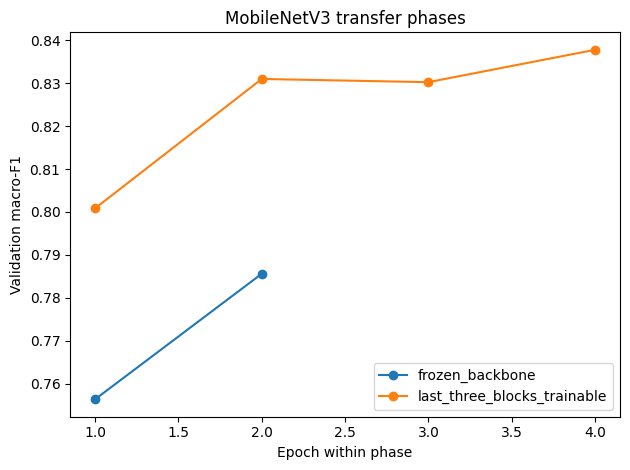

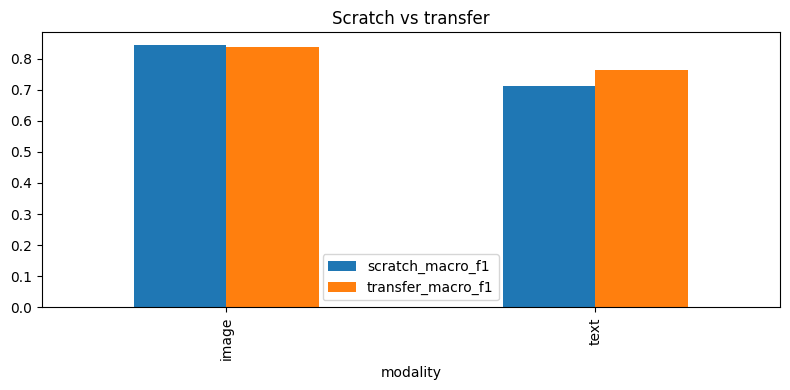

In [2]:
for phase, group in history.groupby("phase"):
    plt.plot(
        range(1, len(group) + 1),
        group["val_macro_f1"],
        marker="o",
        label=phase,
    )
plt.xlabel("Epoch within phase")
plt.ylabel("Validation macro-F1")
plt.title("MobileNetV3 transfer phases")
plt.legend()
plt.tight_layout()
plt.show()

comparison.plot.bar(
    x="modality",
    y=["scratch_macro_f1", "transfer_macro_f1"],
    figsize=(8, 4),
    title="Scratch vs transfer",
)
plt.tight_layout()
plt.show()


## Final Conclusion

Best image transfer model: mobilenet_v3_small_partial_finetune with macro-F1=0.8377; scratch image macro-F1=0.8422. Best text transfer model: minilm_frozen_embeddings_logreg with macro-F1=0.7646; scratch text macro-F1=0.7108. MobileNetV3 was selected for a strong accuracy-to-cost ratio on 4 GB VRAM. MiniLM was kept frozen to obtain semantic representations with low task-training cost. Final selections balance validation macro-F1, inference time, model size, and training cost.
